In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('hospital-data.csv')
df.head()

,caseid,subjectid,casestart,caseend,anestart,aneend,opstart,opend,adm,dis,...,intraop_colloid,intraop_ppf,intraop_mdz,intraop_ftn,intraop_rocu,intraop_vecu,intraop_eph,intraop_phe,intraop_epi,intraop_ca
0,1,5955,0,11542,-552,10848.0,1668,10368,-236220,627780,...,0,120,0.0,100,70,0,10,0,0,0
1,2,2487,0,15741,-1039,14921.0,1721,14621,-221160,1506840,...,0,150,0.0,0,100,0,20,0,0,0
2,3,2861,0,4394,-590,4210.0,1090,3010,-218640,40560,...,0,0,0.0,0,50,0,0,0,0,0
3,4,1903,0,20990,-778,20222.0,2522,17822,-201120,576480,...,0,80,0.0,100,100,0,50,0,0,0
4,5,4416,0,21531,-1009,22391.0,2591,20291,-67560,3734040,...,0,0,0.0,0,160,0,10,900,0,2100


/var/folders/jx/dr80n_1n4s3flx3lb29pzrl00000gn/T/ipykernel_69295/2038941317.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mort_by_age = df.groupby('age_group')['death_inhosp'].mean().reset_index()


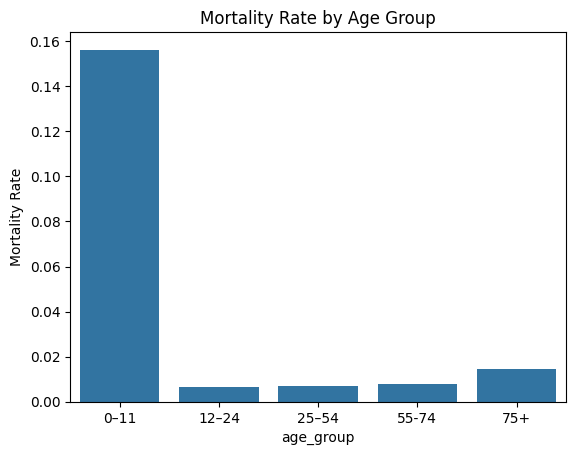

In [6]:
df['age_group'] = pd.cut(df['age'], bins=[0, 11, 24, 54, 74, 120],
                         labels=['0–11', '12–24', '25–54', '55-74', '75+'])

mort_by_age = df.groupby('age_group')['death_inhosp'].mean().reset_index()

sns.barplot(data=mort_by_age, x='age_group', y='death_inhosp')
plt.ylabel("Mortality Rate")
plt.title("Mortality Rate by Age Group")
plt.show()

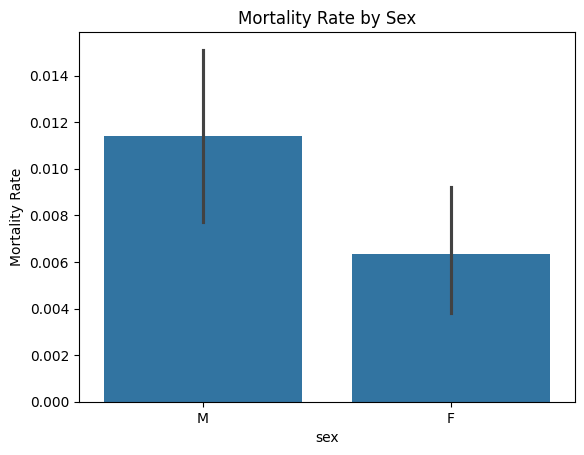

In [8]:
sns.barplot(data=df, x='sex', y='death_inhosp')
plt.ylabel("Mortality Rate")
plt.title("Mortality Rate by Sex")
plt.show()

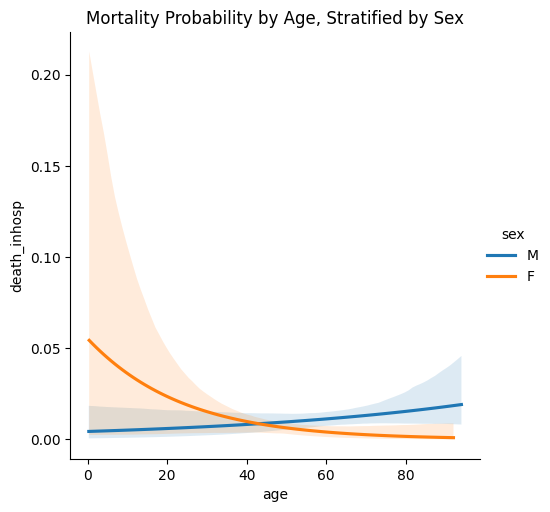

In [9]:
sns.lmplot(
    data=df, x='age', y='death_inhosp',
    hue='sex', logistic=True, scatter=False
)
plt.title("Mortality Probability by Age, Stratified by Sex")
plt.show()

/var/folders/jx/dr80n_1n4s3flx3lb29pzrl00000gn/T/ipykernel_69295/1820612656.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  icu_by_age = df.groupby('age_group')['icu_days'].mean().reset_index()


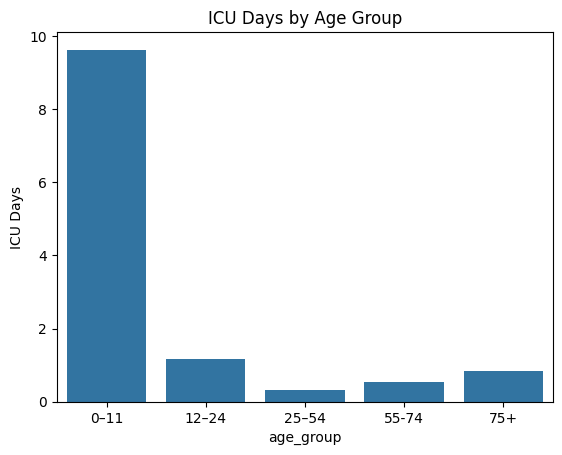

In [16]:
icu_by_age = df.groupby('age_group')['icu_days'].mean().reset_index()

sns.barplot(data=icu_by_age, x='age_group', y='icu_days')
plt.ylabel("ICU Days")
plt.title("ICU Days by Age Group")
plt.show()

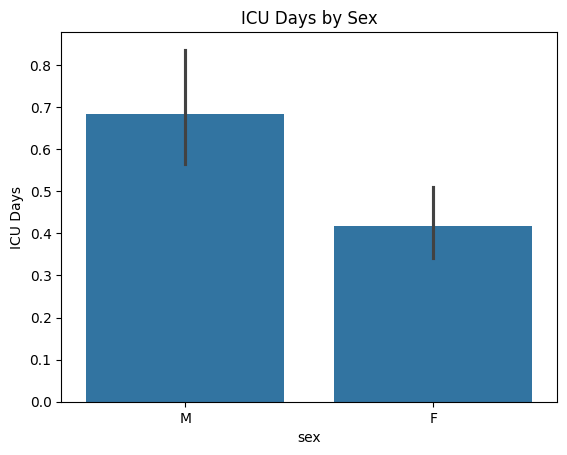

In [19]:
sns.barplot(data=df, x='sex', y='icu_days')
plt.ylabel("ICU Days")
plt.title("ICU Days by Sex")
plt.show()

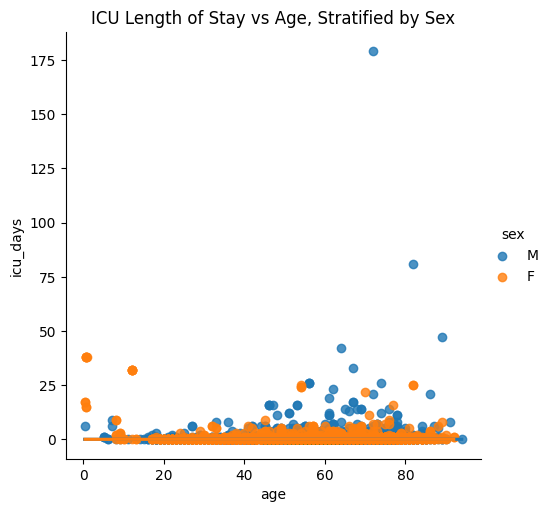

In [24]:
sns.lmplot(
    data=df, x='age', y='icu_days',
    hue='sex',
    lowess=True
)
plt.title("ICU Length of Stay vs Age, Stratified by Sex")
plt.show()